# 01 — Data quality overview

> **Synthetic demonstration.** Every record used below is generated locally and
> is not a CIGEFI-UCR observation. The schemas and injected failure modes mirror
> the recovered archive so the public QC workflow remains executable.

The objective is to retain source identity and raw values while
making structural, temporal, value, and provenance concerns independently
auditable. Flags are created before `temperature_clean_c` is derived.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src" / "weather_pipeline").exists()
)
sys.path.insert(0, str(ROOT / "src"))
SAMPLE = ROOT / "data" / "sample"
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
from weather_pipeline import (
    apply_quality_flags,
    concatenate_sources,
    load_campbell_csv,
    load_davis_30min_csv,
    load_davis_interval_extrema_csv,
)

campbell = load_campbell_csv(
    SAMPLE / "synthetic_campbell_hourly.csv",
    source="synthetic_campbell_hourly",
    instrument="Synthetic Campbell-like source",
)
davis = load_davis_30min_csv(
    SAMPLE / "synthetic_davis_30min.csv",
    source="synthetic_davis_30min",
    instrument="Synthetic Davis-like source",
)
extrema = load_davis_interval_extrema_csv(
    SAMPLE / "synthetic_davis_5min_extrema.csv",
    source="synthetic_davis_5min_interval_extrema",
    instrument="Synthetic Davis-like source",
)
observations = apply_quality_flags(
    concatenate_sources([campbell, davis, extrema])
)


In [3]:
from weather_pipeline import detect_gaps, source_summary

summary = source_summary(observations)
display(summary)

,source,instrument,native_frequency,measurement_type,records,valid_timestamps,unique_timestamps,start,end,qc_pass_records,flagged_records
0,synthetic_campbell_hourly,Synthetic Campbell-like source,1h,air_temperature,2163,2161,2160,2017-04-17 12:00:00,2017-07-16 11:00:00,2157,6
1,synthetic_davis_30min,Synthetic Davis-like source,30min,air_temperature,4317,4317,4316,2017-04-17 12:00:00,2017-07-16 11:30:00,4313,4
2,synthetic_davis_5min_interval_extrema,Synthetic Davis-like source,5min,interval_maximum,4032,4032,4032,2017-09-13 00:00:00,2017-09-26 23:55:00,4031,1
3,synthetic_davis_5min_interval_extrema,Synthetic Davis-like source,5min,interval_minimum,4032,4032,4032,2017-09-13 00:00:00,2017-09-26 23:55:00,4031,1


The five-minute source appears twice because maximum and minimum
are distinct interval statistics. They are intentionally not mixed with
`air_temperature`.

In [4]:
flag_columns = [
    column
    for column in observations.columns
    if column.startswith("qc_") and column not in {"qc_pass", "qc_reasons"}
]
flag_summary = (
    observations[flag_columns]
    .sum()
    .rename("flagged_records")
    .to_frame()
    .assign(percent=lambda data: 100 * data["flagged_records"] / len(observations))
    .sort_values("flagged_records", ascending=False)
)
display(flag_summary)

gaps = detect_gaps(observations)
display(gaps.head())

,flagged_records,percent
qc_temporal_jump,4,0.027503
qc_duplicate,4,0.027503
qc_missing_temperature,3,0.020627
qc_invalid_timestamp,2,0.013751
qc_physical_range,2,0.013751
qc_ingest_structure,1,0.006876
qc_non_numeric_temperature,1,0.006876
qc_out_of_order,1,0.006876
qc_gap_after_previous,1,0.006876
qc_unexpected_interval,1,0.006876


,source,instrument,measurement_type,native_frequency,previous_timestamp,next_timestamp,gap_start,gap_end,missing_intervals,elapsed
0,synthetic_davis_30min,Synthetic Davis-like source,air_temperature,30min,2017-04-23 17:30:00,2017-04-23 20:00:00,2017-04-23 18:00:00,2017-04-23 19:30:00,4,0 days 02:30:00


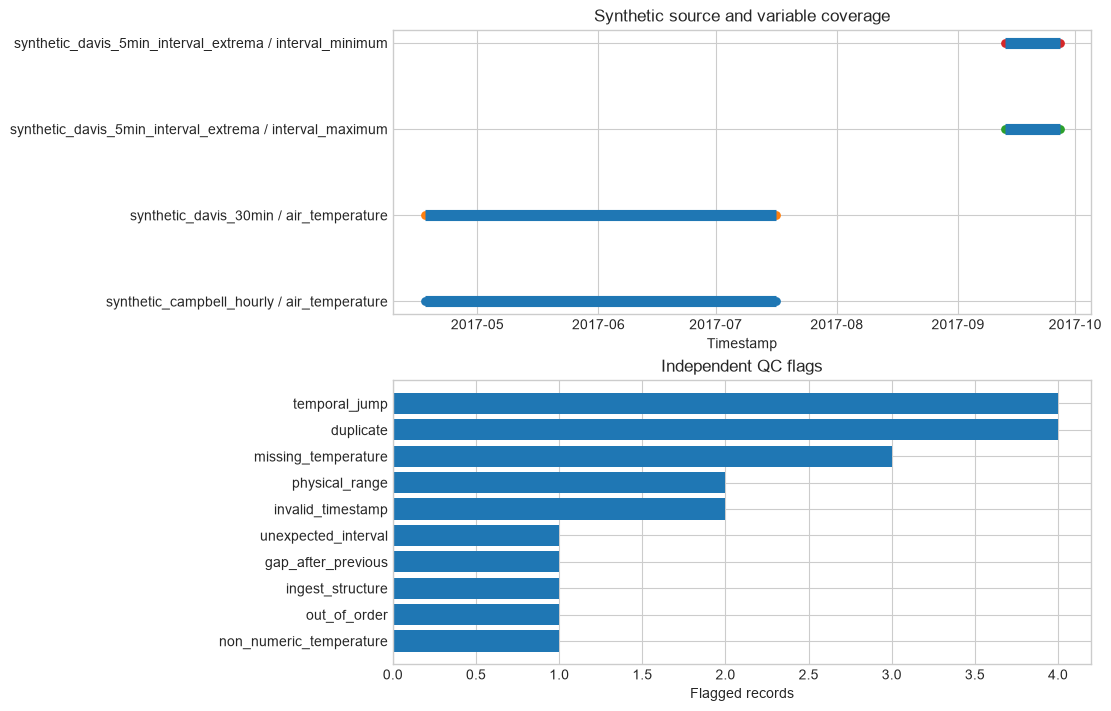

WindowsPath('figures/demo_data_quality_overview.png')

In [5]:
coverage = summary.sort_values(["source", "measurement_type"]).reset_index(drop=True)
labels = coverage["source"] + " / " + coverage["measurement_type"]
nonzero_flags = flag_summary.query("flagged_records > 0").sort_values("flagged_records")

fig, (timeline, flags) = plt.subplots(2, 1, figsize=(11, 7), constrained_layout=True)
for position, row in coverage.iterrows():
    timeline.hlines(position, row["start"], row["end"], linewidth=8)
    timeline.scatter([row["start"], row["end"]], [position, position], s=28)
timeline.set_yticks(range(len(labels)), labels)
timeline.set_title("Synthetic source and variable coverage")
timeline.set_xlabel("Timestamp")

flags.barh(nonzero_flags.index.str.replace("qc_", "", regex=False), nonzero_flags["flagged_records"])
flags.set_title("Independent QC flags")
flags.set_xlabel("Flagged records")

output = FIGURES / "demo_data_quality_overview.png"
fig.savefig(output, dpi=160, bbox_inches="tight")
plt.show()
output.relative_to(ROOT)

In [6]:
analysis_ready = observations.loc[
    observations["qc_pass"] & observations["measurement_type"].eq("air_temperature")
].copy()
print(f"Normalized records: {len(observations):,}")
print(f"QC-passing air-temperature records: {len(analysis_ready):,}")
display(
    analysis_ready[
        [
            "timestamp",
            "temperature_raw_c",
            "temperature_clean_c",
            "source",
            "source_file",
            "native_frequency",
            "qc_pass",
        ]
    ].head()
)

Normalized records: 14,544
QC-passing air-temperature records: 6,470


,timestamp,temperature_raw_c,temperature_clean_c,source,source_file,native_frequency,qc_pass
0,2017-04-17 12:00:00,25.18,25.18,synthetic_campbell_hourly,synthetic_campbell_hourly.csv,1h,True
1,2017-04-17 13:00:00,25.56,25.56,synthetic_campbell_hourly,synthetic_campbell_hourly.csv,1h,True
2,2017-04-17 14:00:00,25.70,25.70,synthetic_campbell_hourly,synthetic_campbell_hourly.csv,1h,True
3,2017-04-17 15:00:00,25.57,25.57,synthetic_campbell_hourly,synthetic_campbell_hourly.csv,1h,True
4,2017-04-17 16:00:00,25.20,25.20,synthetic_campbell_hourly,synthetic_campbell_hourly.csv,1h,True


No flagged row is deleted from `observations`. The
`analysis_ready` view is a downstream choice, and the source file and native
frequency remain attached to every selected record.